# Lab 2

### Accel FFT

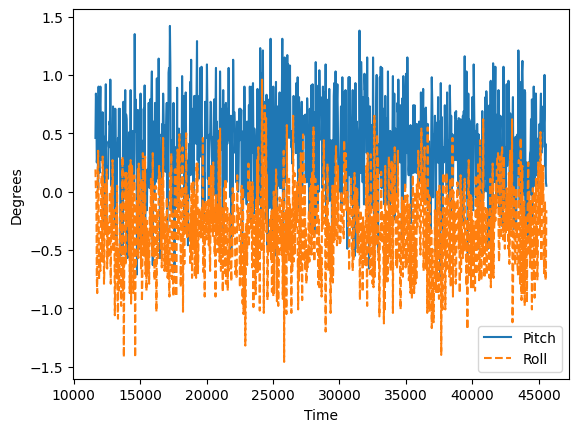

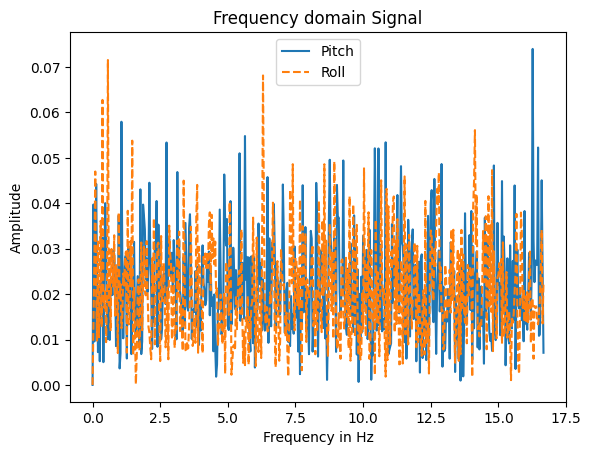

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft
import pandas as pd

pi = np.pi

# Load the CSV
df = pd.read_csv("AccelNoise.csv")


pitch = df["Pitch"].to_numpy()
roll  = df["Roll"].to_numpy()
t     = df["Time"].to_numpy()

sample_rate = 1 / 0.030
N = len(pitch)

plt.plot(t, pitch, label="Pitch", linestyle='-')
plt.plot(t, roll, label="Roll", linestyle='--')
plt.legend()
plt.xlabel("Time")
plt.ylabel("Degrees")
plt.show()

pitch0 = pitch - np.mean(pitch)
roll0  = roll  - np.mean(roll)

freq_pitch = np.fft.rfft(pitch0)
freq_roll  = np.fft.rfft(roll0)

frequency = np.fft.rfftfreq(N, d=1/sample_rate)

y_pitch = (2/N) * np.abs(freq_pitch)
y_roll  = (2/N) * np.abs(freq_roll)

plt.plot(frequency, y_pitch, label="Pitch", linestyle='-')
plt.plot(frequency, y_roll, label="Roll", linestyle='--')
plt.legend()
plt.title("Frequency domain Signal")
plt.xlabel("Frequency in Hz")
plt.ylabel("Amplitude")
plt.show()